---
title: "Forecasting de Temperaturas con Open-Meteo y ARIMA"
description: "Extracción de datos mediante API REST, transformación con Pandas y predicción de series temporales."
author: "Gabriel Sánchez"
date: "2026-09-04"
categories: [API, Python, Pandas, Time Series]
image: "grafica.png"
---

## 1. Introducción y Objetivos del Ejercicio

El análisis de series temporales (*Time Series Forecasting*) es fundamental para anticipar patrones climáticos, consumo energético y demanda operativa. 

En este proyecto práctico implemento un flujo integral (*end-to-end*) para la predicción de temperaturas máximas:

1) **Extracción automatizada de datos:** Consumo de la API REST pública de **Open-Meteo** para la zona costera de Puçol (Valencia) de los últimos 30 días.

2) **Ingesta y estructuración:** Procesamiento del payload en JSON a DataFrames de `pandas`.

3) **Análisis Exploratorio (EDA):** Detección de rangos térmicos y visualización de tendencias de viento.

4) **Forecasting comparativo (5 días vista):** 

   - Modelo heurístico/baseline mediante **Medias Móviles (Moving Averages)**.

   - Modelado estadístico adaptativo mediante **ARIMA/SARIMA** utilizando búsqueda automática de hiperparámetros (`pmdarima.auto_arima`).

In [ ]:
#| include: false

%pip install requests pandas
%pip install pmdarima

Note: you may need to restart the kernel to use updated packages.
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/723.3 kB ? eta -:--:--
   ---------------------------------------- 723.3/723.3 kB 5.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------  2.9/2.9 MB 24.3 MB/s eta 0:00:01
   --------------------------

## 2. Preparación del Entorno

Instalamos y cargamos las librerías necesarias. Destaca el uso de `requests` para las peticiones HTTP y `pmdarima` para el ajuste algorítmico de parámetros $(p, d, q)$ de series temporales.

In [ ]:
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import requests
import json
from datetime import datetime
import os

## 3. Extracción de Datos Vía API REST

Conectamos con la API meteorológica de **Open-Meteo**, parametrizando las coordenadas geográficas de la playa de Puçol (`lat: 39.61, lon: -0.26`), la zona horaria peninsular y un histórico de 30 días retrospectivos.

In [ ]:
#| code-fold: true
#| output: false

response = requests.get("https://api.open-meteo.com/v1/forecast?latitude=39.61&longitude=-0.26&daily=temperature_2m_max,temperature_2m_min,wind_speed_10m_max,precipitation_sum&timezone=Europe%2FMadrid&past_days=30")

if response.status_code == 200: 
    data_json = response.json()

#data_json

{'latitude': 39.625,
 'longitude': -0.3125,
 'generationtime_ms': 18.177509307861328,
 'utc_offset_seconds': 7200,
 'timezone': 'Europe/Madrid',
 'timezone_abbreviation': 'GMT+2',
 'elevation': 0.0,
 'daily_units': {'time': 'iso8601',
  'temperature_2m_max': '°C',
  'temperature_2m_min': '°C',
  'wind_speed_10m_max': 'km/h',
  'precipitation_sum': 'mm'},
 'daily': {'time': ['2026-08-04',
   '2026-08-05',
   '2026-08-06',
   '2026-08-07',
   '2026-08-08',
   '2026-08-09',
   '2026-08-10',
   '2026-08-11',
   '2026-08-12',
   '2026-08-13',
   '2026-08-14',
   '2026-08-15',
   '2026-08-16',
   '2026-08-17',
   '2026-08-18',
   '2026-08-19',
   '2026-08-20',
   '2026-08-21',
   '2026-08-22',
   '2026-08-23',
   '2026-08-24',
   '2026-08-25',
   '2026-08-26',
   '2026-08-27',
   '2026-08-28',
   '2026-08-29',
   '2026-08-30',
   '2026-08-31',
   '2026-09-01',
   '2026-09-02',
   '2026-09-03',
   '2026-09-04',
   '2026-09-05',
   '2026-09-06',
   '2026-09-07',
   '2026-09-08',
   '2026-09-09

## 4. Transformación de JSON a Pandas DataFrame

El endpoint devuelve las métricas en un diccionario anidado bajo la clave `daily`. Lo aplanamos en un DataFrame tabular estructurado para su posterior análisis.

In [23]:
datos_diarios = data_json['daily']

df = pd.DataFrame(datos_diarios)
df.head()


,time,temperature_2m_max,temperature_2m_min,wind_speed_10m_max,precipitation_sum
0,2026-08-04,31.7,23.1,18.3,0.0
1,2026-08-05,31.9,23.8,18.5,0.0
2,2026-08-06,31.4,24.8,17.4,0.0
3,2026-08-07,32.2,24.1,16.9,0.0
4,2026-08-08,32.6,24.0,17.7,0.0


## 5. Análisis Exploratorio y Métricas Clave

Calculamos las medias del periodo para obtener una referencia base del comportamiento climático y trazamos la evolución de las rachas de viento.

------------------------------

Temperatura Maxima 2m: 31.85

Temperatura Minima 2m: 23.29

Velocidad Maxima del Viento 10m: 18.08

Suma de Precipitaciones: 0.03
------------------------------


<Axes: title={'center': 'Velocidad del viento en la playa de Puçol (Km/H)'}, xlabel='time'>

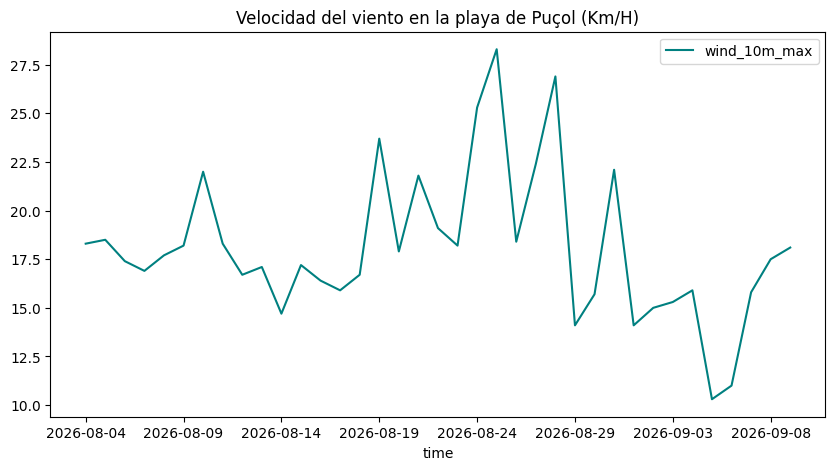

In [39]:
##Seleccionamos las 4 variables y sacamos la media
df.rename(columns = {'temperature_2m_max':'temp_2m_max', 'temperature_2m_min':'temp_2m_min', 'wind_speed_10m_max':'wind_10m_max', 'precipitation_sum':'precip_sum'}, inplace=True)

medias = df[['temp_2m_max', 'temp_2m_min', 'wind_10m_max', 'precip_sum']].mean().round(2)

print("------------------------------")
print()
print(f"Temperatura Maxima 2m: {medias['temp_2m_max']}")
print()
print(f"Temperatura Minima 2m: {medias['temp_2m_min']}")
print()
print(f"Velocidad Maxima del Viento 10m: {medias['wind_10m_max']}")
print()
print(f"Suma de Precipitaciones: {medias['precip_sum']}")
print("------------------------------")

##Usamos el PLOT propio de Pandas para sacar una gráfica de la velocidad del tiempo
df.plot(
    x = "time", 
    y = "wind_10m_max", 
    kind = "line", 
    title = "Velocidad del viento en la playa de Puçol (Km/H)", 
    color = "teal", 
    figsize = (10, 5)
)



> **Observación del EDA:** El registro muestra una temperatura máxima promedio de ~31.8°C y eventos puntuales de viento de hasta 28 km/h[cite: 1]. Existe una anomalía térmica visible en torno al día 19 de agosto con picos superiores a 40°C[cite: 1], un factor que pondrá a prueba la robustez de los modelos predictivos.

## 6. Modelado Predictivo: Medias Móviles (Baseline)

Implementamos un pronóstico autorregresivo simple mediante una media móvil con ventana deslizante ($k=3$) para proyectar los siguientes 5 periodos[cite: 1]. En cada iteración, la predicción calculada se reinyecta en el histórico para estimar el siguiente paso[cite: 1].

In [51]:
#Medias Moviles con Pandas con ventana de 3 días y predicción de 5 
n_periods = 5
k = 3

#Hacemos una copia de los datos reales en forma de lista
historial_para_ma = df['temp_2m_max'].tolist()
predicciones_ma = []

#Bucle iterativo para el forecast
for i in range(n_periods):
    #Seleccionamos los últimos k valores
    ventana = historial_para_ma[-k:]
    #Calculamos la media de esa ventana
    siguiente_pred = sum(ventana) / k
    #Lo guardamos en predicciones_ma
    predicciones_ma.append(siguiente_pred)
    #Y se añade al historial para usarlo en la siguiente vuelta
    historial_para_ma.append(siguiente_pred)



## 7. Modelado Estadístico Avanzado: Auto-ARIMA

A diferencia de las medias móviles simples, el enfoque **ARIMA** (*AutoRegressive Integrated Moving Average*) modela la autocorrelación de la serie, estacionariza los datos y captura componentes estacionales ($m=7$ días)[cite: 1]. 

Utilizamos el algoritmo stepwise de `pmdarima` para minimizar el criterio de información de Akaike (AIC), convergiendo hacia la mejor combinación de parámetros $(p,d,q)(P,D,Q)_m$[cite: 1].


In [ ]:
#Forecasting con ARIMA

#Ajuste automatico del modelo como el auto.arima() de R
modelo_sarima = pm.auto_arima(
    df['temp_2m_max'], 
    seasonal=True, 
    m=7, 
    stepwise=True, 
    trace=True
)

#Guardamos las predicciones en una predicción de 5 días
predicciones = modelo_sarima.predict(n_periods=5)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=179.576, Time=0.30 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=174.687, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=171.988, Time=0.15 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=173.015, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=363.330, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=170.002, Time=0.01 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=171.988, Time=0.05 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=173.926, Time=0.18 sec
 ARIMA(2,0,0)(0,0,0)[7] intercept   : AIC=171.950, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=171.966, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=171.023, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[7] intercept   : AIC=173.985, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[7]             : AIC=inf, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[7] intercept
Total fit time: 0.932 seconds


## 8. Evaluación y Comparativa de Predicciones

Comparamos la proyección de ambos métodos a 5 días vista respecto al histórico real de temperaturas máximas registradas[cite: 1].

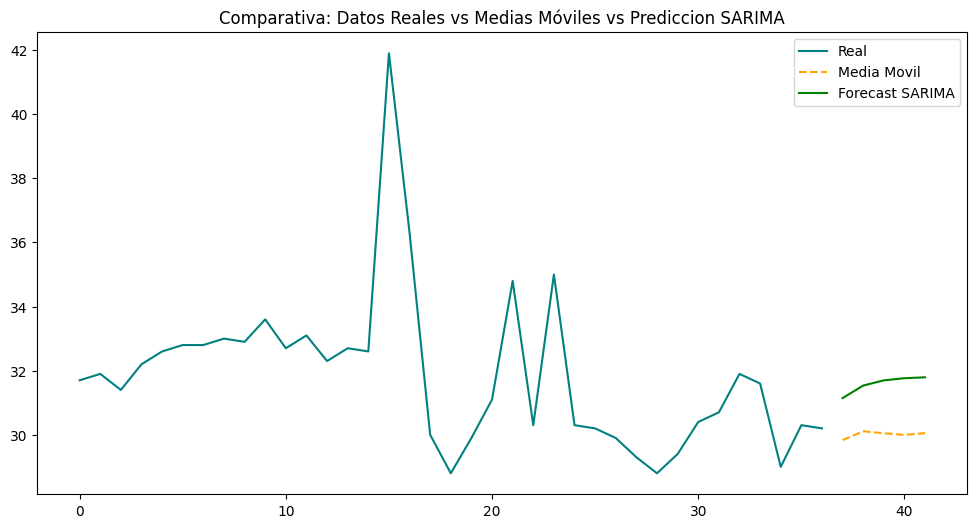

In [ ]:
# Gráfico con las nuevas predicciones

#Cremos un índice numérico que continúe justo cuando acaba el DF
ultimo_indice = df.index[-1]
indice_futuro = range(ultimo_indice + 1, ultimo_indice + 1 + n_periods)

#Convertimos la lista de predicciones en una Serie de Pandas con ese índice
serie_forecast_ma = pd.Series(predicciones_ma, index=indice_futuro)




#Se prepara primero la figura
plt.figure(figsize=(12, 6))

#Se añaden las capas. Primero los datos reales
plt.plot(df.index, df['temp_2m_max'], label = 'Real', color="teal")
#Ahora Medias Moviles
plt.plot(serie_forecast_ma.index, serie_forecast_ma, label = "Media Movil", color='orange', linestyle='--')
#Ahora Predicciones Sarima
plt.plot(predicciones.index, predicciones, label="Forecast SARIMA", color="green")

plt.title('Comparativa: Datos Reales vs Medias Móviles vs Prediccion SARIMA')
plt.legend()
plt.show()

### Conclusiones y Aprendizajes

* **Suavizado de medias móviles:** El enfoque MA reacciona con lentitud a las tendencias recientes y tiende a estabilizarse rápido en un valor plano al propagar sus propias predicciones[cite: 1].

* **Comportamiento de ARIMA:** El modelo autorregresivo identificado incorpora mejor la inercia reciente de la serie sin verse distorsionado de forma permanente por picos térmicos aislados[cite: 1].

* **Siguientes pasos:** Incorporar variables exógenas mediante modelos SARIMAX (p. ej. radiación solar o viento cruzado) o explorar redes recurrentes (LSTM) para horizontes de predicción más extensos.